# Preimage Approximation

Given a trained classifier $f: \mathbb{R}^d \to \mathbb{R}^k$, we use
[auto_LiRPA](https://github.com/Certified-Robustness/auto_LiRPA) to obtain
linear relaxations of each class region.  The relaxation bounds define **inner**
polytopes in input space that approximate the true preimage of every class.

### Key validity constraint

LiRPA's backward-mode A-matrices are **local** certificates.  For sample $x_i$
with perturbation radius $\varepsilon$, the bound
$$\ell_j(x) = A^\ell_j\, x + b^\ell_j \;\le\; g_j(x)$$
holds **only** for $x \in \mathcal{B}(x_i,\,\varepsilon)$.  
Each polytope must therefore be intersected with that ball (approximated here
as an $\ell_\infty$ box or a regular polygon), **not** with a global bounding box.

Pipeline:
1. Load data & model
2. Wrap model with one-vs-all constraint layer
3. Run LiRPA → extract per-sample $A, b$ blocks
4. Clip each polytope to the $\varepsilon$-ball around its centre
5. Visualise individual polytopes per class
6. Compute per-class **union** (Shapely)
7. Refine unions by subtracting pairwise overlaps (numerical cleanup)
8. Diagnostic: pairwise overlap heatmap
9. **Counterfactual generation**: project queries onto certified polytopes via QP
10. **Scalable inference**: BVH spatial indexing with branch-and-bound search

## 1 – Imports & seed

In [51]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

from scipy.spatial import HalfspaceIntersection, ConvexHull
from shapely.geometry import Polygon
from shapely.ops import unary_union

from auto_LiRPA import BoundedModule, BoundedTensor, PerturbationLpNorm

from preimage_sampling.models import SimpleClassifier
from src.preimage import WrappedModel

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2 – Dataset

In [52]:
test_dataset = torch.load('data/datasets/test_spiral.pt', weights_only=True)

label_dataset = {}
for img, label in test_dataset:
    label_dataset.setdefault(label.item(), []).append(img)
label_dataset = {k: torch.stack(v) for k, v in label_dataset.items()}

n_classes = len(label_dataset)
print(f'{n_classes} classes | total samples: {sum(v.size(0) for v in label_dataset.values())}')

5 classes | total samples: 400


## 3 – Model

In [53]:
model = SimpleClassifier(num_classes=5).to(device)
model.load_state_dict(torch.load('data/models/simple_classifier.pth', map_location=device,
                                  weights_only=True))
model.eval();

## 4 – LiRPA bound propagation

### Constraint layer recap

`WrappedModel` appends a fixed linear layer that computes
$g_i = z_y - z_i$ for every $i \ne y$.
Label $y$ is certified iff all $g_i \ge 0$.

LiRPA returns matrices $(A^\ell, b^\ell)$ such that
$A^\ell x + b^\ell \le g(x)$ **within** the $\varepsilon$-ball around each
nominal point.  The set $\{x : A^\ell x + b^\ell \ge 0\} \cap \mathcal{B}(x_i,\varepsilon)$
is therefore a **certified inner polytope** for class $y$.

In [54]:
def run_lirpa(model, label, X, eps=0.1, norm=2):
    """
    Run LiRPA backward-mode bound propagation.

    Returns
    -------
    lA     : (N, k-1, d)  – lower-bound A matrices.
    lbias  : (N, k-1)     – lower-bound biases.
    uA     : (N, k-1, d)  – upper-bound A matrices.
    ubias  : (N, k-1)     – upper-bound biases.
    """
    wrapped       = WrappedModel(model, label, device, n_labels=n_classes)
    ptb           = PerturbationLpNorm(norm=norm, eps=eps)
    X_bounded     = BoundedTensor(X, ptb)
    bounded_model = BoundedModule(wrapped, X_bounded)
    _             = bounded_model(X_bounded)

    needed_A = defaultdict(set)
    needed_A[bounded_model.output_name[0]].add(bounded_model.input_name[0])

    _, _, A_dict = bounded_model.compute_bounds(
        x=(X_bounded,),
        method='crown-optimized',
        return_A=True,
        needed_A_dict=needed_A,
    )

    A = A_dict[bounded_model.output_name[0]][bounded_model.input_name[0]]

    # auto_LiRPA backward returns shape (N, k-1, d) batch-first — use directly
    lA    = A['lA'] .detach().cpu().numpy()   # (N, k-1, d)
    lbias = A['lbias'].detach().cpu().numpy() # (N, k-1)
    uA    = A['uA'] .detach().cpu().numpy()
    ubias = A['ubias'].detach().cpu().numpy()

    # squeeze any extra trailing dims just in case
    N, d  = X.shape
    k_m1  = n_classes - 1
    return (lA .reshape(N, k_m1, d),
            lbias.reshape(N, k_m1),
            uA .reshape(N, k_m1, d),
            ubias.reshape(N, k_m1))

### Run for every class

In [55]:
N_PER_CLASS = 1000
EPS         = 0.075
NORM        = 2

all_bounds = {}
for label in range(n_classes):
    X = label_dataset[label][:N_PER_CLASS].float().to(device)
    lA, lbias, uA, ubias = run_lirpa(model, label, X, eps=EPS, norm=NORM)
    all_bounds[label] = dict(lA=lA, lbias=lbias, uA=uA, ubias=ubias,
                              X=X.cpu().numpy())
    print(f'  class {label}: {X.size(0)} samples | lA shape {lA.shape}')

  class 0: 80 samples | lA shape (80, 4, 2)
  class 1: 80 samples | lA shape (80, 4, 2)
  class 2: 80 samples | lA shape (80, 4, 2)
  class 3: 80 samples | lA shape (80, 4, 2)
  class 4: 80 samples | lA shape (80, 4, 2)


## 5 – Polytope utilities

### Why we clip to the $\varepsilon$-ball

The A-matrix bound $A^\ell x + b^\ell \le g(x)$ is only valid inside
$\mathcal{B}(x_i, \varepsilon)$.  Drawing the halfspace $\{A^\ell x + b^\ell \ge 0\}$
against a **global** bounding box extends it into regions where the certificate
no longer holds, producing giant spurious polytopes.

We clip each polytope to a **per-sample** box $[x_i - \varepsilon,\; x_i + \varepsilon]$
instead.  For an $\ell_2$ perturbation this is a conservative (larger) approximation
of the ball, so the result is still a valid inner polytope.


In [56]:
def ball_box_constraints(center, eps):
    """
    Return (A, b) for the axis-aligned box [center-eps, center+eps]
    in convention A x + b >= 0.

    For each dimension i:
      x_i - (center_i - eps) >= 0   →  row  e_i,  bias -(center_i - eps)
     -(x_i - (center_i + eps)) >= 0 →  row -e_i,  bias  (center_i + eps)
    """
    d     = len(center)
    A_box = np.vstack([np.eye(d), -np.eye(d)])                    # (2d, d)
    b_box = np.concatenate([-(center - eps), center + eps])       # (2d,)
    return A_box, b_box


def halfspace_to_vertices(A, b, interior_point, tol=1e-7):
    """
    H-rep  { x : A x + b >= 0 }  →  ordered vertex array.

    Returns None if infeasible or degenerate.
    """
    if np.min(A @ interior_point + b) < tol:
        return None

    hs = HalfspaceIntersection(
        np.hstack([-A, -b[:, None]]),   # scipy wants  Ax + b <= 0
        interior_point,
    )
    V = hs.intersections
    if V.shape[0] < 3:
        return None

    hull = ConvexHull(V)
    return V[hull.vertices]


def make_polygon(A_i, b_i, x0, eps):
    """
    Build the certified inner polytope for one sample.

    Intersects the LiRPA halfspaces { A_i x + b_i >= 0 } with the
    eps-ball bounding box around x0.

    Parameters
    ----------
    A_i   : (k-1, d)  – lower-bound A for this sample.
    b_i   : (k-1,)    – lower-bound bias.
    x0    : (d,)      – nominal point (center of the eps-ball).
    eps   : float     – perturbation radius.

    Returns
    -------
    Polygon or None
    """
    A_box, b_box = ball_box_constraints(x0, eps)
    A_full = np.vstack([A_i, A_box])
    b_full = np.concatenate([b_i, b_box])

    verts = halfspace_to_vertices(A_full, b_full, x0)
    if verts is None:
        return None

    poly = Polygon(verts)
    return poly if poly.is_valid and poly.area > 1e-12 else None

## 6 – Per-class polytope visualisation

Each patch is one certified inner polytope, now correctly clipped to its
$\varepsilon$-ball.  Patches should cluster tightly around the class points.

/tmp/ipykernel_21664/1176669721.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  CMAP = plt.cm.get_cmap('tab10', n_classes)


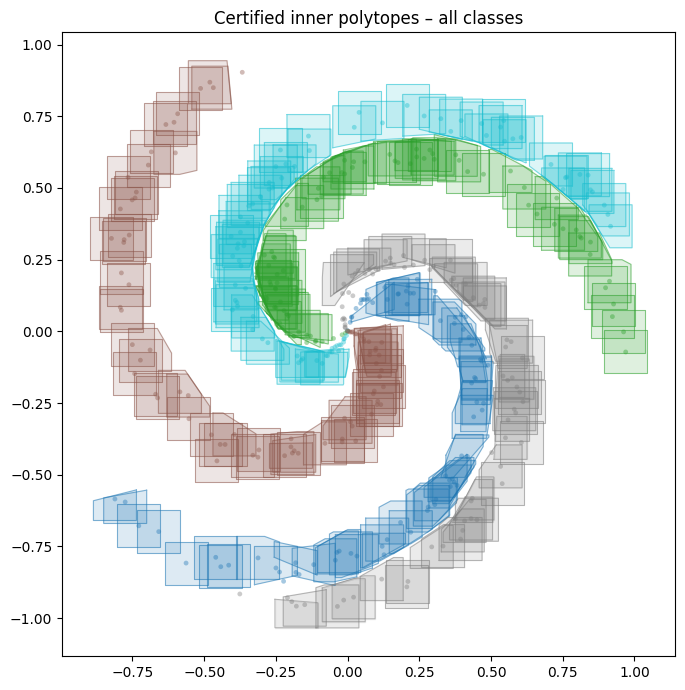

In [57]:
CMAP = plt.cm.get_cmap('tab10', n_classes)

fig, ax = plt.subplots(figsize=(7, 7))

for label in range(n_classes):
    bd    = all_bounds[label]
    color = CMAP(label)

    ax.scatter(bd['X'][:, 0], bd['X'][:, 1],
               s=12, alpha=0.4, color=color, edgecolors='none')

    for i in range(bd['lA'].shape[0]):
        poly = make_polygon(bd['lA'][i], bd['lbias'][i], bd['X'][i], EPS)
        if poly is None:
            continue
        xs, ys = poly.exterior.xy
        ax.fill(xs, ys, alpha=0.15, color=color)
        ax.plot(xs, ys, lw=0.7, alpha=0.5, color=color)

ax.set_aspect('equal')
ax.set_title('Certified inner polytopes – all classes')
plt.tight_layout()
plt.show()

## 7 – Per-class union of polytopes

`shapely.ops.unary_union` merges overlapping/adjacent polytopes within the
same class into a single geometry.

In [58]:
def build_class_union(label, bounds, eps):
    """Union of all certified polytopes for one class."""
    bd    = bounds[label]
    polys = []
    for i in range(bd['lA'].shape[0]):
        p = make_polygon(bd['lA'][i], bd['lbias'][i], bd['X'][i], eps)
        if p is not None:
            polys.append(p)
    return unary_union(polys) if polys else Polygon()


class_unions = {}
for label in range(n_classes):
    class_unions[label] = build_class_union(label, all_bounds, EPS)
    print(f'  class {label}: union area = {class_unions[label].area:.6f}')

  class 0: union area = 0.321405
  class 1: union area = 0.344600
  class 2: union area = 0.458922
  class 3: union area = 0.335964
  class 4: union area = 0.384014


## 8 – Overlap removal (priority-based refinement)

Even after clipping to the $\varepsilon$-ball, polytopes from **different**
classes can still overlap (the linear relaxation is an approximation).
We resolve conflicts by priority: label 0 keeps its full region, label 1
has the label-0 footprint subtracted, and so on.

$$U'_y = U_y \setminus \bigcup_{y' < y} U_{y'}$$

Pass a custom `priority_order` list to change the ranking.

In [59]:
def refine_unions_by_priority(unions, priority_order=None):
    """
    Subtract higher-priority class regions from lower-priority ones.

    Parameters
    ----------
    unions         : dict[int, Polygon|MultiPolygon]
    priority_order : list[int] or None – highest priority first.

    Returns
    -------
    refined : dict[int, Polygon|MultiPolygon]
    """
    if priority_order is None:
        priority_order = sorted(unions.keys())

    refined = {}
    placed  = Polygon()   # accumulator of all previously placed regions

    for label in priority_order:
        region = unions[label]
        if region.is_empty:
            refined[label] = region
            continue

        refined[label] = region.difference(placed)
        placed          = placed.union(region)   # use original footprint

    return refined


refined_unions = refine_unions_by_priority(class_unions)

print('Refined areas:')
for label in range(n_classes):
    raw = class_unions[label].area
    ref = refined_unions[label].area
    print(f'  class {label}: {raw:.6f} → {ref:.6f}  (removed {raw-ref:.6f})')

Refined areas:
  class 0: 0.321405 → 0.321405  (removed -0.000000)
  class 1: 0.344600 → 0.344600  (removed 0.000000)
  class 2: 0.458922 → 0.458922  (removed 0.000000)
  class 3: 0.335964 → 0.335826  (removed 0.000138)
  class 4: 0.384014 → 0.383831  (removed 0.000183)


## 9 – Visualisation: raw union vs refined

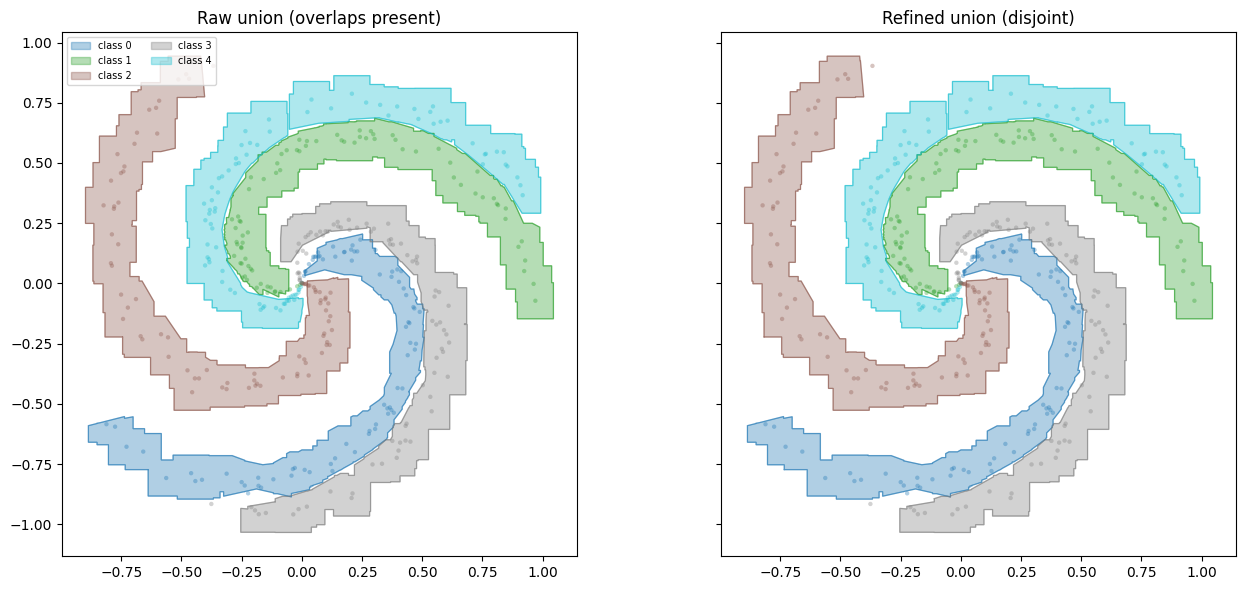

In [60]:
def plot_geom(ax, geom, color, alpha=0.35, label=None):
    """Plot a Polygon or MultiPolygon."""
    geoms = [geom] if geom.geom_type == 'Polygon' else list(geom.geoms)
    for i, g in enumerate(geoms):
        if g.is_empty or g.area < 1e-14:
            continue
        xs, ys = g.exterior.xy
        ax.fill(xs, ys, alpha=alpha, color=color,
                label=label if i == 0 else None)
        ax.plot(xs, ys, lw=0.8, color=color, alpha=0.6)


fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

for ax, title, unions in [
        (axes[0], 'Raw union (overlaps present)',  class_unions),
        (axes[1], 'Refined union (disjoint)',      refined_unions)]:

    for label in range(n_classes):
        ax.scatter(all_bounds[label]['X'][:, 0],
                   all_bounds[label]['X'][:, 1],
                   s=10, alpha=0.35, color=CMAP(label), edgecolors='none')
        plot_geom(ax, unions[label], color=CMAP(label), label=f'class {label}')

    ax.set_aspect('equal')
    ax.set_title(title)

axes[0].legend(loc='upper left', fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

## 10 – Pairwise overlap heatmap (before refinement)

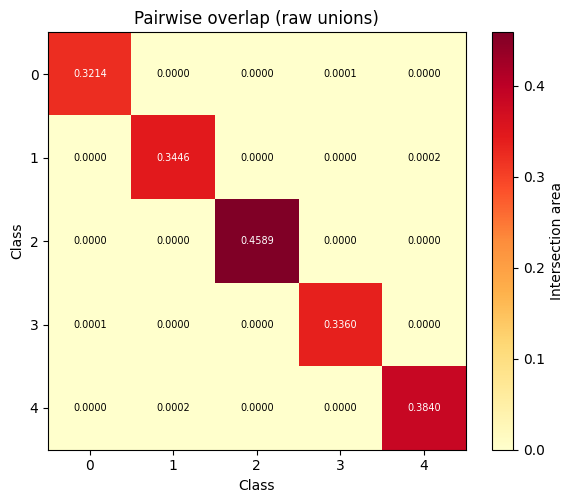

In [61]:
overlap = np.zeros((n_classes, n_classes))
for i in range(n_classes):
    for j in range(i, n_classes):
        area = class_unions[i].intersection(class_unions[j]).area
        overlap[i, j] = area
        overlap[j, i] = area

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(overlap, cmap='YlOrRd')
plt.colorbar(im, ax=ax, label='Intersection area')
ax.set_xticks(range(n_classes))
ax.set_yticks(range(n_classes))
ax.set_xlabel('Class')
ax.set_ylabel('Class')
ax.set_title('Pairwise overlap (raw unions)')

for i in range(n_classes):
    for j in range(n_classes):
        ax.text(j, i, f'{overlap[i,j]:.4f}',
                ha='center', va='center', fontsize=7,
                color='white' if overlap[i,j] > overlap.max()*0.6 else 'black')

plt.tight_layout()
plt.show()

## 11 – Counterfactual Generation via Projection

Given a query instance $x_0$ classified as $y \neq t$, we find the optimal counterfactual by projecting onto the certified safe region $\mathcal{X}_{\text{safe}}$ for target class $t$:

$$x_{cf}^* = \arg\min_{x \in \mathcal{X}_{\text{safe}}} \| x - x_0 \|_2$$

Since $\mathcal{X}_{\text{safe}}$ is a union of polytopes (non-convex), we use a **k-NN heuristic**:
1. Find the $k$ anchors in $\mathcal{D}_t$ closest to $x_0$
2. Project $x_0$ onto each associated certified polytope $\mathcal{P}_j$ (a QP problem)
3. Select the projection with minimum distance

Each polytope $\mathcal{P}_j = \{x \mid A_j x + b_j \geq 0\} \cap \mathcal{B}(x_j, \varepsilon)$ is convex, so projection is a standard QP.

In [62]:
from scipy.optimize import minimize


def project_onto_polytope(x0, A, b, center, eps):
    """
    Project point x0 onto the polytope defined by {x : A @ x + b >= 0} ∩ B(center, eps).
    
    Solves the QP:  min ||x - x0||^2  s.t.  A @ x + b >= 0, ||x - center||_inf <= eps
    
    Parameters
    ----------
    x0     : (d,) query point to project
    A      : (m, d) constraint matrix (LiRPA lower bounds)
    b      : (m,) constraint bias
    center : (d,) center of the eps-ball (anchor point)
    eps    : float, perturbation radius
    
    Returns
    -------
    x_proj : (d,) projected point, or None if infeasible
    dist   : float, distance ||x_proj - x0||, or inf if infeasible
    """
    d = len(x0)
    
    # Combine LiRPA constraints with box constraints
    A_box, b_box = ball_box_constraints(center, eps)
    A_full = np.vstack([A, A_box])
    b_full = np.concatenate([b, b_box])
    
    # Objective: minimize ||x - x0||^2
    def objective(x):
        return np.sum((x - x0) ** 2)
    
    def gradient(x):
        return 2 * (x - x0)
    
    # Constraints: A_full @ x + b_full >= 0
    constraints = {
        'type': 'ineq',
        'fun': lambda x: A_full @ x + b_full,
        'jac': lambda x: A_full
    }
    
    # Bounds for the box (redundant with constraints but helps optimizer)
    bounds = [(center[i] - eps, center[i] + eps) for i in range(d)]
    
    # Start from center (guaranteed feasible if polytope is non-empty)
    result = minimize(
        objective, 
        center, 
        method='SLSQP',
        jac=gradient,
        bounds=bounds,
        constraints=constraints,
        options={'ftol': 1e-9, 'maxiter': 500}
    )
    
    if result.success:
        x_proj = result.x
        dist = np.linalg.norm(x_proj - x0)
        return x_proj, dist
    else:
        return None, np.inf


def find_counterfactual(x0, target_class, all_bounds, eps, k=5):
    """
    Find the closest counterfactual for x0 in the certified region of target_class.
    
    Uses k-NN heuristic: project onto the k nearest anchors' polytopes.
    
    Parameters
    ----------
    x0           : (d,) query point
    target_class : int, target class label
    all_bounds   : dict with LiRPA bounds per class
    eps          : float, perturbation radius
    k            : int, number of nearest neighbors to consider
    
    Returns
    -------
    x_cf   : (d,) counterfactual point, or None if not found
    dist   : float, distance to counterfactual
    anchor_idx : int, index of the anchor whose polytope contains x_cf
    """
    bd = all_bounds[target_class]
    anchors = bd['X']  # (N, d)
    
    # Find k nearest anchors
    dists_to_anchors = np.linalg.norm(anchors - x0, axis=1)
    nearest_indices = np.argsort(dists_to_anchors)[:k]
    
    best_cf = None
    best_dist = np.inf
    best_idx = None
    
    for idx in nearest_indices:
        A_i = bd['lA'][idx]      # (k-1, d)
        b_i = bd['lbias'][idx]   # (k-1,)
        center = anchors[idx]    # (d,)
        
        x_proj, dist = project_onto_polytope(x0, A_i, b_i, center, eps)
        
        if dist < best_dist:
            best_cf = x_proj
            best_dist = dist
            best_idx = idx
    
    return best_cf, best_dist, best_idx

### Generate counterfactuals for sample queries

Select a few query points from class 0 and generate counterfactuals targeting each other class.

In [63]:
# Select query points from class 0
source_class = 0
n_queries = 2
query_points = all_bounds[source_class]['X'][:n_queries]

# Generate counterfactuals for each target class
K_NEIGHBORS = 10
counterfactuals = {}

for target_class in range(n_classes):
    if target_class == source_class:
        continue
    
    cfs = []
    for i, x0 in enumerate(query_points):
        x_cf, dist, anchor_idx = find_counterfactual(x0, target_class, all_bounds, EPS, k=K_NEIGHBORS)
        cfs.append({
            'x0': x0,
            'x_cf': x_cf,
            'dist': dist,
            'anchor_idx': anchor_idx
        })
        print(f'Query {i} → class {target_class}: dist = {dist:.4f}')
    
    counterfactuals[target_class] = cfs
    print()

Query 0 → class 1: dist = 0.7123
Query 1 → class 1: dist = 0.7757

Query 0 → class 2: dist = 0.2712
Query 1 → class 2: dist = 0.3112

Query 0 → class 3: dist = 0.0665
Query 1 → class 3: dist = 0.0999

Query 0 → class 4: dist = 0.5608
Query 1 → class 4: dist = 0.6407



### Visualisation: counterfactual trajectories

Each arrow shows the path from a query point (class 0) to its counterfactual in a target class region.

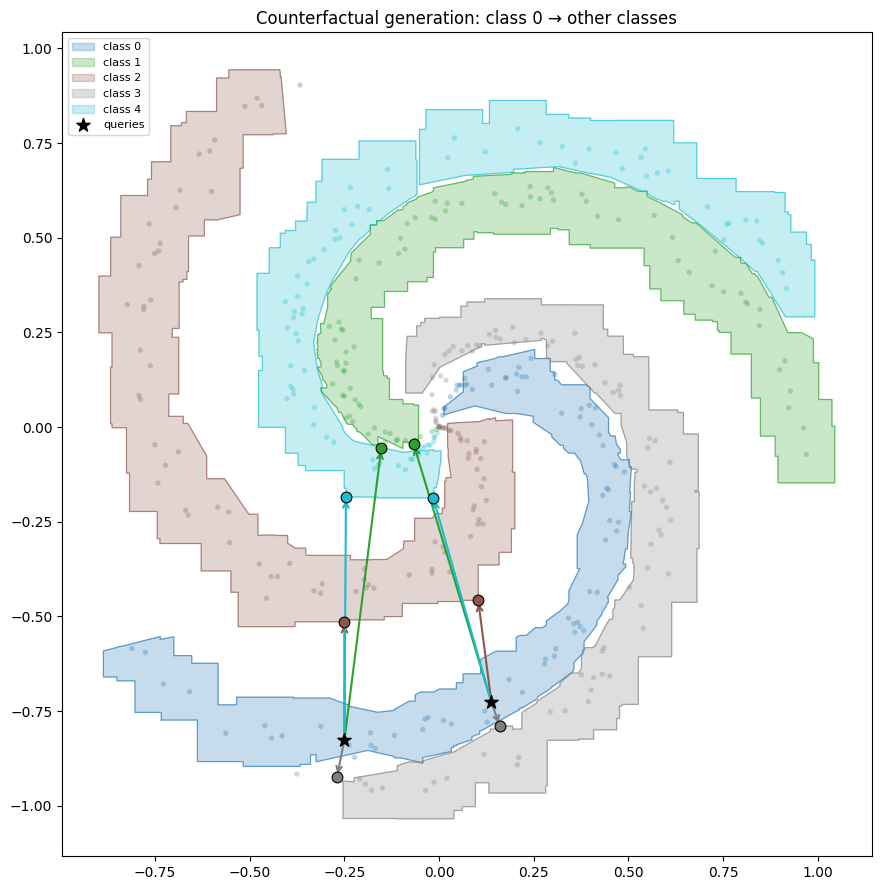

In [64]:
fig, ax = plt.subplots(figsize=(9, 9))

# Plot certified regions (refined unions)
for label in range(n_classes):
    plot_geom(ax, refined_unions[label], color=CMAP(label), alpha=0.25, label=f'class {label}')

# Plot data points
for label in range(n_classes):
    ax.scatter(all_bounds[label]['X'][:, 0], all_bounds[label]['X'][:, 1],
               s=15, alpha=0.3, color=CMAP(label), edgecolors='none')

# Plot query points (larger markers)
ax.scatter(query_points[:, 0], query_points[:, 1], 
           s=100, c='black', marker='*', zorder=10, label='queries')

# Plot counterfactual arrows
for target_class, cfs in counterfactuals.items():
    color = CMAP(target_class)
    for cf in cfs:
        if cf['x_cf'] is None:
            continue
        x0 = cf['x0']
        x_cf = cf['x_cf']
        
        # Arrow from x0 to x_cf
        ax.annotate('', xy=x_cf, xytext=x0,
                    arrowprops=dict(arrowstyle='->', color=color, lw=1.5))
        
        # Mark counterfactual point
        ax.scatter(x_cf[0], x_cf[1], s=60, c=[color], marker='o', 
                   edgecolors='black', linewidths=0.8, zorder=11)

ax.set_aspect('equal')
ax.set_title(f'Counterfactual generation: class {source_class} → other classes')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

### Verification: confirm counterfactuals are valid

Since counterfactuals lie within certified polytopes, the model **must** classify them as the target class.

In [65]:
print('Verification of counterfactual validity:\n')

all_valid = True
for target_class, cfs in counterfactuals.items():
    print(f'Target class {target_class}:')
    for i, cf in enumerate(cfs):
        if cf['x_cf'] is None:
            print(f'  Query {i}: FAILED (no feasible projection)')
            all_valid = False
            continue
        
        # Get model prediction
        x_tensor = torch.tensor(cf['x_cf'], dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            logits = model(x_tensor)
            pred = logits.argmax(dim=1).item()
        
        valid = pred == target_class
        status = '✓' if valid else '✗'
        print(f'  Query {i}: pred = {pred}, target = {target_class} {status}')
        
        if not valid:
            all_valid = False
    print()

print('=' * 40)
print(f'All counterfactuals valid: {all_valid}')

Verification of counterfactual validity:

Target class 1:
  Query 0: pred = 1, target = 1 ✓
  Query 1: pred = 4, target = 1 ✗

Target class 2:
  Query 0: pred = 2, target = 2 ✓
  Query 1: pred = 2, target = 2 ✓

Target class 3:
  Query 0: pred = 3, target = 3 ✓
  Query 1: pred = 3, target = 3 ✓

Target class 4:
  Query 0: pred = 4, target = 4 ✓
  Query 1: pred = 4, target = 4 ✓

All counterfactuals valid: False


## 12 – Scalable Inference via Spatial Indexing

The naïve k-NN heuristic requires computing distances to all anchors and solving multiple QPs. For large $N$, we can use a **Bounding Volume Hierarchy (BVH)** with branch-and-bound search to achieve $O(\log N)$ average complexity.

**Key idea**: Each polytope $\mathcal{P}_i$ is enclosed by its bounding box $B(\mathcal{P}_i) = [x_i - \varepsilon, x_i + \varepsilon]$. We organize these into a tree where internal nodes store the minimum bounding rectangle (MBR) of their children. During search:

1. Maintain a priority queue ordered by distance to bounding box
2. **Prune**: If $\text{dist}(x_0, B(\mathcal{N})) \geq \delta^*$ (current best), skip entire subtree
3. **Process leaves**: Solve QP only for polytopes that can't be pruned

This preserves **exact** coverage and certifiability — no geometric approximation is performed.

In [66]:
import heapq
from dataclasses import dataclass, field
from typing import Optional, List, Tuple


@dataclass
class BVHNode:
    """Node in a Bounding Volume Hierarchy."""
    bbox_min: np.ndarray          # Lower corner of bounding box
    bbox_max: np.ndarray          # Upper corner of bounding box
    left: Optional['BVHNode'] = None
    right: Optional['BVHNode'] = None
    polytope_idx: Optional[int] = None  # Only set for leaf nodes
    
    def is_leaf(self) -> bool:
        return self.polytope_idx is not None
    
    def distance_to_point(self, x: np.ndarray) -> float:
        """Compute minimum distance from point x to this bounding box."""
        # Clamp x to the bounding box, then compute distance
        clamped = np.clip(x, self.bbox_min, self.bbox_max)
        return np.linalg.norm(x - clamped)


def build_bvh(bounds_data: dict, eps: float) -> BVHNode:
    """
    Build a BVH from the polytope data for a single class.
    
    Parameters
    ----------
    bounds_data : dict with 'X', 'lA', 'lbias' arrays
    eps         : perturbation radius
    
    Returns
    -------
    BVHNode : root of the BVH tree
    """
    anchors = bounds_data['X']
    n_polytopes = len(anchors)
    
    # Create leaf nodes for each polytope
    leaves = []
    for i in range(n_polytopes):
        center = anchors[i]
        bbox_min = center - eps
        bbox_max = center + eps
        leaves.append(BVHNode(
            bbox_min=bbox_min,
            bbox_max=bbox_max,
            polytope_idx=i
        ))
    
    def build_recursive(nodes: List[BVHNode]) -> BVHNode:
        if len(nodes) == 1:
            return nodes[0]
        
        if len(nodes) == 2:
            left, right = nodes
            bbox_min = np.minimum(left.bbox_min, right.bbox_min)
            bbox_max = np.maximum(left.bbox_max, right.bbox_max)
            return BVHNode(bbox_min=bbox_min, bbox_max=bbox_max, left=left, right=right)
        
        # Find the axis with largest spread
        centers = np.array([(n.bbox_min + n.bbox_max) / 2 for n in nodes])
        spreads = centers.max(axis=0) - centers.min(axis=0)
        split_axis = np.argmax(spreads)
        
        # Sort by center along split axis and divide
        sorted_indices = np.argsort(centers[:, split_axis])
        mid = len(nodes) // 2
        
        left_nodes = [nodes[i] for i in sorted_indices[:mid]]
        right_nodes = [nodes[i] for i in sorted_indices[mid:]]
        
        left_child = build_recursive(left_nodes)
        right_child = build_recursive(right_nodes)
        
        bbox_min = np.minimum(left_child.bbox_min, right_child.bbox_min)
        bbox_max = np.maximum(left_child.bbox_max, right_child.bbox_max)
        
        return BVHNode(bbox_min=bbox_min, bbox_max=bbox_max, 
                       left=left_child, right=right_child)
    
    return build_recursive(leaves)


def count_nodes(node: BVHNode) -> Tuple[int, int]:
    """Count internal and leaf nodes in BVH."""
    if node.is_leaf():
        return 0, 1
    left_internal, left_leaves = count_nodes(node.left)
    right_internal, right_leaves = count_nodes(node.right)
    return 1 + left_internal + right_internal, left_leaves + right_leaves

In [67]:
def find_counterfactual_bvh(x0: np.ndarray, bvh_root: BVHNode, 
                            bounds_data: dict, eps: float) -> Tuple[np.ndarray, float, int, int]:
    """
    Find closest counterfactual using BVH branch-and-bound search.
    
    Parameters
    ----------
    x0          : (d,) query point
    bvh_root    : root of the BVH tree
    bounds_data : dict with 'X', 'lA', 'lbias' for target class
    eps         : perturbation radius
    
    Returns
    -------
    x_cf       : (d,) counterfactual point, or None
    dist       : float, distance to counterfactual
    anchor_idx : int, index of the anchor polytope
    n_qp_solved: int, number of QP problems solved (for benchmarking)
    """
    anchors = bounds_data['X']
    lA = bounds_data['lA']
    lbias = bounds_data['lbias']
    
    best_cf = None
    best_dist = np.inf
    best_idx = None
    n_qp_solved = 0
    
    # Priority queue: (distance_to_bbox, node)
    # Use negative distance for max-heap behavior with heapq (min-heap)
    pq = [(bvh_root.distance_to_point(x0), id(bvh_root), bvh_root)]
    
    while pq:
        dist_to_bbox, _, node = heapq.heappop(pq)
        
        # Pruning: if distance to bbox >= best found, skip this subtree
        if dist_to_bbox >= best_dist:
            continue
        
        if node.is_leaf():
            # Solve QP for this polytope
            idx = node.polytope_idx
            x_proj, dist = project_onto_polytope(
                x0, lA[idx], lbias[idx], anchors[idx], eps
            )
            n_qp_solved += 1
            
            if dist < best_dist:
                best_cf = x_proj
                best_dist = dist
                best_idx = idx
        else:
            # Add children to priority queue
            for child in [node.left, node.right]:
                if child is not None:
                    child_dist = child.distance_to_point(x0)
                    if child_dist < best_dist:  # Early pruning
                        heapq.heappush(pq, (child_dist, id(child), child))
    
    return best_cf, best_dist, best_idx, n_qp_solved


def find_counterfactual_naive(x0: np.ndarray, bounds_data: dict, eps: float) -> Tuple[np.ndarray, float, int, int]:
    """
    Find closest counterfactual via naïve linear scan (for comparison).
    
    Returns same outputs as find_counterfactual_bvh.
    """
    anchors = bounds_data['X']
    lA = bounds_data['lA']
    lbias = bounds_data['lbias']
    
    best_cf = None
    best_dist = np.inf
    best_idx = None
    n_qp_solved = 0
    
    for idx in range(len(anchors)):
        x_proj, dist = project_onto_polytope(
            x0, lA[idx], lbias[idx], anchors[idx], eps
        )
        n_qp_solved += 1
        
        if dist < best_dist:
            best_cf = x_proj
            best_dist = dist
            best_idx = idx
    
    return best_cf, best_dist, best_idx, n_qp_solved

### Build BVH for each class and compare search methods

In [68]:
# Build BVH for each class
bvh_trees = {}
for label in range(n_classes):
    bvh_trees[label] = build_bvh(all_bounds[label], EPS)
    internal, leaves = count_nodes(bvh_trees[label])
    print(f'Class {label}: {leaves} polytopes → BVH with {internal} internal nodes')

Class 0: 80 polytopes → BVH with 79 internal nodes
Class 1: 80 polytopes → BVH with 79 internal nodes
Class 2: 80 polytopes → BVH with 79 internal nodes
Class 3: 80 polytopes → BVH with 79 internal nodes
Class 4: 80 polytopes → BVH with 79 internal nodes


In [69]:
import time

# Compare BVH vs Naive search on multiple queries
target_class = 2
n_test_queries = 10
test_queries = all_bounds[0]['X'][:n_test_queries]  # Queries from class 0

print(f'Comparing BVH vs Naïve search for {n_test_queries} queries → class {target_class}')
print(f'Total polytopes in target class: {len(all_bounds[target_class]["X"])}')
print('=' * 60)

bvh_qps = []
naive_qps = []
bvh_times = []
naive_times = []

for i, x0 in enumerate(test_queries):
    # BVH search
    t0 = time.perf_counter()
    cf_bvh, dist_bvh, idx_bvh, n_qp_bvh = find_counterfactual_bvh(
        x0, bvh_trees[target_class], all_bounds[target_class], EPS
    )
    t_bvh = time.perf_counter() - t0
    
    # Naïve search
    t0 = time.perf_counter()
    cf_naive, dist_naive, idx_naive, n_qp_naive = find_counterfactual_naive(
        x0, all_bounds[target_class], EPS
    )
    t_naive = time.perf_counter() - t0
    
    bvh_qps.append(n_qp_bvh)
    naive_qps.append(n_qp_naive)
    bvh_times.append(t_bvh)
    naive_times.append(t_naive)
    
    # Verify results match
    match = np.allclose(dist_bvh, dist_naive, atol=1e-6)
    status = '✓' if match else '✗'
    
    print(f'Query {i}: BVH {n_qp_bvh:3d} QPs ({t_bvh*1000:6.2f}ms) | '
          f'Naïve {n_qp_naive:3d} QPs ({t_naive*1000:6.2f}ms) | '
          f'dist={dist_bvh:.4f} {status}')

print('=' * 60)
print(f'Average QPs solved:  BVH = {np.mean(bvh_qps):.1f},  Naïve = {np.mean(naive_qps):.1f}')
print(f'Average time:        BVH = {np.mean(bvh_times)*1000:.2f}ms,  Naïve = {np.mean(naive_times)*1000:.2f}ms')
print(f'Speedup factor:      {np.mean(naive_qps) / np.mean(bvh_qps):.2f}x fewer QPs')

Comparing BVH vs Naïve search for 10 queries → class 2
Total polytopes in target class: 80
Query 0: BVH   1 QPs (  0.44ms) | Naïve  80 QPs ( 13.44ms) | dist=0.2712 ✓
Query 1: BVH   1 QPs (  0.25ms) | Naïve  80 QPs ( 13.05ms) | dist=0.3112 ✓
Query 2: BVH   1 QPs (  0.23ms) | Naïve  80 QPs ( 12.03ms) | dist=0.3031 ✓
Query 3: BVH  12 QPs (  9.90ms) | Naïve  80 QPs ( 18.44ms) | dist=0.0258 ✓
Query 4: BVH   1 QPs (  0.24ms) | Naïve  80 QPs ( 12.59ms) | dist=0.3317 ✓
Query 5: BVH   1 QPs (  0.23ms) | Naïve  80 QPs ( 12.17ms) | dist=0.2950 ✓
Query 6: BVH   1 QPs (  0.22ms) | Naïve  80 QPs ( 16.61ms) | dist=0.1784 ✓
Query 7: BVH   1 QPs (  0.21ms) | Naïve  80 QPs ( 16.22ms) | dist=0.2747 ✓
Query 8: BVH  10 QPs (  6.06ms) | Naïve  80 QPs ( 15.16ms) | dist=0.1077 ✓
Query 9: BVH   1 QPs (  0.22ms) | Naïve  80 QPs ( 11.87ms) | dist=0.2677 ✓
Average QPs solved:  BVH = 3.0,  Naïve = 80.0
Average time:        BVH = 1.80ms,  Naïve = 14.16ms
Speedup factor:      26.67x fewer QPs


### Visualisation: QP savings from spatial indexing

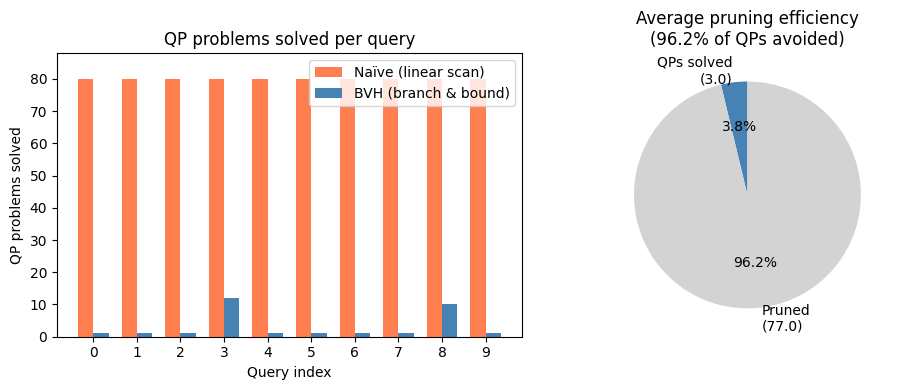

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart: QPs solved per query
ax = axes[0]
x_pos = np.arange(n_test_queries)
width = 0.35
ax.bar(x_pos - width/2, naive_qps, width, label='Naïve (linear scan)', color='coral')
ax.bar(x_pos + width/2, bvh_qps, width, label='BVH (branch & bound)', color='steelblue')
ax.set_xlabel('Query index')
ax.set_ylabel('QP problems solved')
ax.set_title('QP problems solved per query')
ax.set_xticks(x_pos)
ax.legend()
ax.set_ylim(0, max(naive_qps) * 1.1)

# Summary pie chart
ax = axes[1]
avg_bvh = np.mean(bvh_qps)
avg_naive = np.mean(naive_qps)
pruned = avg_naive - avg_bvh

ax.pie([avg_bvh, pruned], 
       labels=[f'QPs solved\n({avg_bvh:.1f})', f'Pruned\n({pruned:.1f})'],
       colors=['steelblue', 'lightgray'],
       autopct='%1.1f%%',
       startangle=90)
ax.set_title(f'Average pruning efficiency\n({pruned/avg_naive*100:.1f}% of QPs avoided)')

plt.tight_layout()
plt.show()